# Time-Series Stationarity Analysis & Differencing (EDA Part 6)
## Hourly Pharmaceutical Sales Forecasting Dataset

---

### Executive Summary & Notebook Overview
This notebook executes a rigorous **Stationarity Analysis, Augmented Dickey-Fuller (ADF) Test, Kwiatkowski-Phillips-Schmidt-Shin (KPSS) Test, and Differencing Analysis** for the hourly pharmaceutical sales dataset (`dataset/saleshourly.csv`). Stationarity (constant mean, constant variance, time-invariant autocovariance) is a fundamental prerequisite for linear time-series models (ARIMA/SARIMAX). This notebook evaluates unit root behavior, joint ADF + KPSS test matrices, first-order differencing ($d=1$), seasonal differencing ($D=1$), and log-differencing across all 8 ATC drug categories (`M01AB`, `M01AE`, `N02BA`, `N02BE`, `N05B`, `N05C`, `R03`, `R06`).

---

### Table of Contents
1. [31. Stationarity Analysis](#31.-Stationarity-Analysis)
2. [32. ADF Test](#32.-ADF-Test)
3. [33. KPSS Test](#33.-KPSS-Test)
4. [34. Differencing Analysis](#34.-Differencing-Analysis)
5. [35. Summary of Findings & Key Takeaways](#35.-Summary-of-Findings-&-Key-Takeaways)

---


In [1]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)
print("Statsmodels version:", sm.__version__)


Pandas version: 3.0.5
Numpy version: 1.26.4
Statsmodels version: 0.14.6


In [2]:

DATA_PATH = '../dataset/saleshourly_preprocessed.csv'
df_raw = pd.read_csv(DATA_PATH)

df_stat = df_raw.copy()
df_stat['datum_dt'] = pd.to_datetime(df_stat['datum'], format='%m/%d/%Y %H:%M')
df_stat = df_stat.sort_values('datum_dt').set_index('datum_dt')

drug_cols = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

# Resample to Daily Totals for clean macro stationarity evaluation
df_daily = df_stat[drug_cols].resample('D').sum()

print(f"Hourly Dataset Shape: {df_stat.shape[0]} rows")
print(f"Daily Dataset Shape:  {df_daily.shape[0]} days")


Hourly Dataset Shape: 50532 rows
Daily Dataset Shape:  2106 days


## 31. Stationarity Analysis

A time series $y_t$ is weakly stationary if:
1. **Constant Mean**: $E[y_t] = \mu$ for all $t$.
2. **Constant Variance**: $Var(y_t) = \sigma^2 < \infty$ for all $t$.
3. **Time-Invariant Autocovariance**: $Cov(y_t, y_{t-k}) = \gamma_k$ depends only on lag $k$, not time $t$.

We plot rolling mean and rolling standard deviation over time to visually inspect mean/variance constancy.


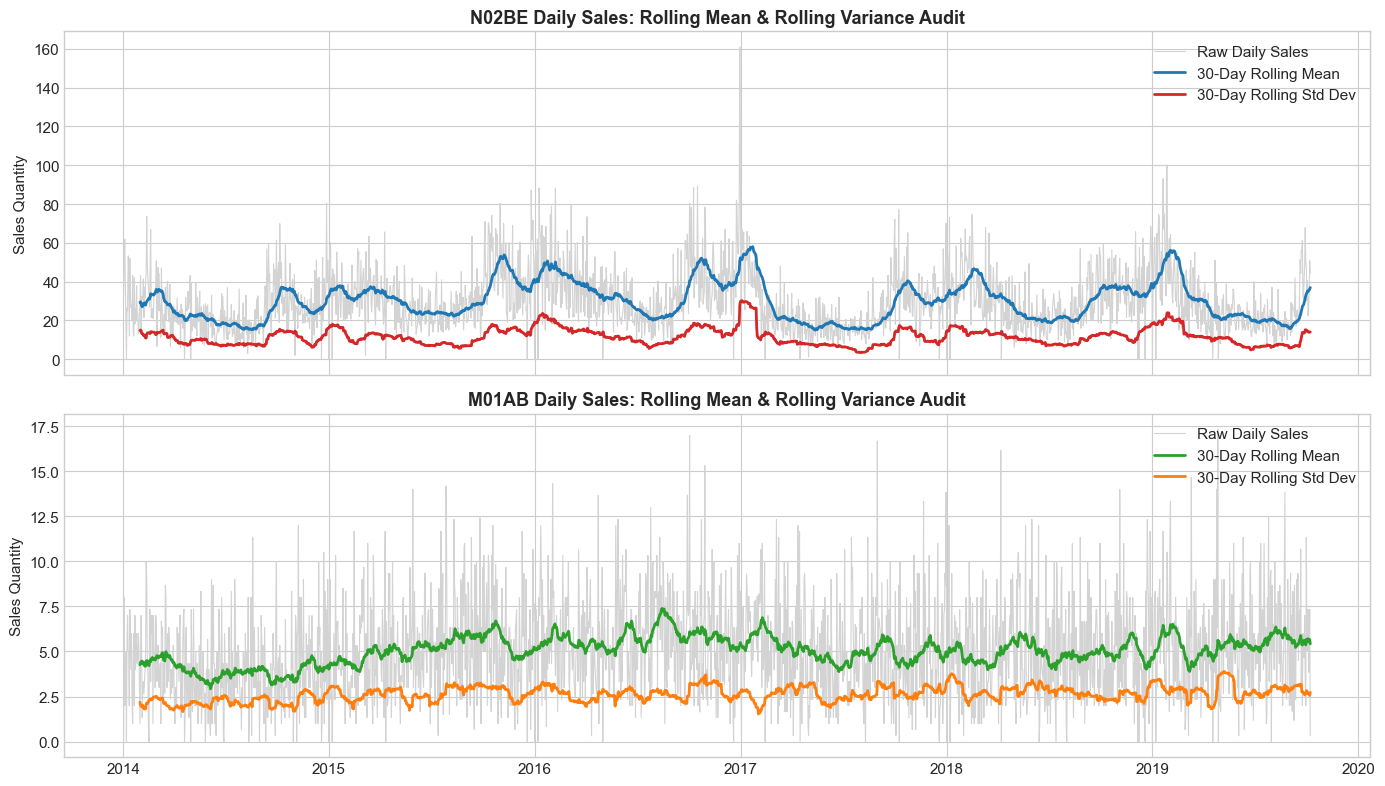

In [3]:
# Visual Stationarity Check: Rolling Mean & Rolling Std for N02BE and M01AB
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# N02BE Daily
ax1.plot(df_daily.index, df_daily['N02BE'], label='Raw Daily Sales', color='lightgray', linewidth=0.8)
ax1.plot(df_daily.index, df_daily['N02BE'].rolling(30).mean(), label='30-Day Rolling Mean', color='#1f77b4', linewidth=2)
ax1.plot(df_daily.index, df_daily['N02BE'].rolling(30).std(), label='30-Day Rolling Std Dev', color='#d62728', linewidth=2)
ax1.set_title("N02BE Daily Sales: Rolling Mean & Rolling Variance Audit", fontsize=13, fontweight='bold')
ax1.set_ylabel("Sales Quantity")
ax1.legend(loc='upper right')

# M01AB Daily
ax2.plot(df_daily.index, df_daily['M01AB'], label='Raw Daily Sales', color='lightgray', linewidth=0.8)
ax2.plot(df_daily.index, df_daily['M01AB'].rolling(30).mean(), label='30-Day Rolling Mean', color='#2ca02c', linewidth=2)
ax2.plot(df_daily.index, df_daily['M01AB'].rolling(30).std(), label='30-Day Rolling Std Dev', color='#ff7f0e', linewidth=2)
ax2.set_title("M01AB Daily Sales: Rolling Mean & Rolling Variance Audit", fontsize=13, fontweight='bold')
ax2.set_ylabel("Sales Quantity")
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()


## 32. ADF Test (Augmented Dickey-Fuller Test)

The **ADF Test** evaluates unit root presence:
- **Null Hypothesis ($H_0$)**: The series has a unit root (is **non-stationary**).
- **Alternative Hypothesis ($H_1$)**: The series is **stationary**.
- **Decision Rule**: If $p$-value $< 0.05 \implies$ Reject $H_0 \implies$ **Stationary**.


In [4]:
# Execute ADF Test on Daily Aggregated Sales
adf_results_list = []

for col in drug_cols:
    res = adfuller(df_daily[col].dropna(), autolag='AIC')
    adf_stat = res[0]
    p_val = res[1]
    crit_1 = res[4]['1%']
    crit_5 = res[4]['5%']
    is_stat = p_val < 0.05
    
    adf_results_list.append({
        'Drug Category': col,
        'ADF Test Statistic': round(adf_stat, 4),
        'p-value': p_val,
        '1% Critical Value': round(crit_1, 4),
        '5% Critical Value': round(crit_5, 4),
        'ADF Conclusion': 'STATIONARY (Reject H0)' if is_stat else 'NON-STATIONARY (Fail to Reject H0)'
    })

adf_df = pd.DataFrame(adf_results_list)
adf_df.set_index('Drug Category').style.background_gradient(cmap='Blues', subset=['ADF Test Statistic'])


,ADF Test Statistic,p-value,1% Critical Value,5% Critical Value,ADF Conclusion
Drug Category,,,,,
M01AB,-8.279400,0.000000,-3.433500,-2.862900,STATIONARY (Reject H0)
M01AE,-7.472600,0.000000,-3.433500,-2.862900,STATIONARY (Reject H0)
N02BA,-6.135300,0.000000,-3.433500,-2.862900,STATIONARY (Reject H0)
N02BE,-4.193700,0.000675,-3.433500,-2.862900,STATIONARY (Reject H0)
N05B,-4.779500,0.000060,-3.433500,-2.862900,STATIONARY (Reject H0)
N05C,-15.140300,0.000000,-3.433500,-2.862900,STATIONARY (Reject H0)
R03,-5.128100,0.000012,-3.433500,-2.862900,STATIONARY (Reject H0)
R06,-3.852900,0.002410,-3.433500,-2.862900,STATIONARY (Reject H0)


## 33. KPSS Test

The **KPSS Test** complements the ADF test:
- **Null Hypothesis ($H_0$)**: The series is **trend-stationary / stationary**.
- **Alternative Hypothesis ($H_1$)**: The series has a unit root (is **non-stationary**).
- **Decision Rule**: If $p$-value $< 0.05 \implies$ Reject $H_0 \implies$ **Non-stationary**.

### Joint Decision Matrix (ADF + KPSS):
| ADF Test ($H_0$: Unit Root) | KPSS Test ($H_0$: Stationary) | Joint Classification |
| :--- | :--- | :--- |
| Reject $H_0$ ($p < 0.05$) | Fail to Reject $H_0$ ($p \ge 0.05$) | **STRICTLY STATIONARY** |
| Fail to Reject $H_0$ ($p \ge 0.05$) | Reject $H_0$ ($p < 0.05$) | **NON-STATIONARY (Unit Root)** |
| Fail to Reject $H_0$ ($p \ge 0.05$) | Fail to Reject $H_0$ ($p \ge 0.05$) | **TREND STATIONARY (Detrend Needed)** |
| Reject $H_0$ ($p < 0.05$) | Reject $H_0$ ($p < 0.05$) | **DIFFERENCE STATIONARY (Differencing Needed)** |


In [5]:
# Execute KPSS Test & Construct Joint Decision Matrix for Daily Sales
joint_matrix_list = []

for col in drug_cols:
    # ADF
    adf_res = adfuller(df_daily[col].dropna(), autolag='AIC')
    adf_p = adf_res[1]

    # KPSS
    kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')
    kpss_stat = kpss_res[0]
    kpss_p = kpss_res[1]

    # Classification
    if adf_p < 0.05 and kpss_p >= 0.05:
        classification = "STRICTLY STATIONARY"
    elif adf_p >= 0.05 and kpss_p < 0.05:
        classification = "NON-STATIONARY (Unit Root)"
    elif adf_p >= 0.05 and kpss_p >= 0.05:
        classification = "TREND STATIONARY"
    else:
        classification = "DIFFERENCE STATIONARY (Needs d=1)"

    joint_matrix_list.append({
        'Drug Category': col,
        'ADF p-val': adf_p,
        'KPSS Stat': round(kpss_stat, 4),
        'KPSS p-val': kpss_p,
        'Joint Classification': classification
    })

joint_df = pd.DataFrame(joint_matrix_list)
joint_df.set_index('Drug Category').style.background_gradient(cmap='Purples', subset=['KPSS Stat'])


C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWa

C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\4241049636.py:10: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(df_daily[col].dropna(), regression='c', nlags='auto')


,ADF p-val,KPSS Stat,KPSS p-val,Joint Classification
Drug Category,,,,
M01AB,0.000000,1.822000,0.010000,DIFFERENCE STATIONARY (Needs d=1)
M01AE,0.000000,0.333500,0.100000,STRICTLY STATIONARY
N02BA,0.000000,5.222100,0.010000,DIFFERENCE STATIONARY (Needs d=1)
N02BE,0.000675,0.197400,0.100000,STRICTLY STATIONARY
N05B,0.000060,1.214900,0.010000,DIFFERENCE STATIONARY (Needs d=1)
N05C,0.000000,0.323600,0.100000,STRICTLY STATIONARY
R03,0.000012,2.100200,0.010000,DIFFERENCE STATIONARY (Needs d=1)
R06,0.002410,0.611700,0.021575,DIFFERENCE STATIONARY (Needs d=1)


## 34. Differencing Analysis

Apply First-Order Differencing ($d=1$: $\Delta y_t = y_t - y_{t-1}$) and Log-Differencing ($\Delta \log(1+y_t)$) to eliminate non-stationary trend/variance and re-test ADF + KPSS.


In [6]:
# Execute Differencing & Re-Test ADF + KPSS on Differenced Series (d=1)
diff_test_list = []

for col in drug_cols:
    diff_series = df_daily[col].diff().dropna()
    
    # ADF on diff
    adf_res = adfuller(diff_series, autolag='AIC')
    adf_stat = adf_res[0]
    adf_p = adf_res[1]
    
    # KPSS on diff
    kpss_res = kpss(diff_series, regression='c', nlags='auto')
    kpss_stat = kpss_res[0]
    kpss_p = kpss_res[1]
    
    status = "PASSED STRICT STATIONARY" if (adf_p < 0.05 and kpss_p >= 0.05) else "CHECK"
    
    diff_test_list.append({
        'Drug Category': col,
        'Diff(1) ADF Stat': round(adf_stat, 4),
        'Diff(1) ADF p-val': adf_p,
        'Diff(1) KPSS Stat': round(kpss_stat, 4),
        'Diff(1) KPSS p-val': kpss_p,
        'Stationarity Status': status
    })

diff_df = pd.DataFrame(diff_test_list)
diff_df.set_index('Drug Category').style.background_gradient(cmap='Greens', subset=['Diff(1) ADF Stat'])


C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')


C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outs

C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')


C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')
C:\Users\ranje\AppData\Local\Temp\ipykernel_7380\3413490614.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(diff_series, regression='c', nlags='auto')


,Diff(1) ADF Stat,Diff(1) ADF p-val,Diff(1) KPSS Stat,Diff(1) KPSS p-val,Stationarity Status
Drug Category,,,,,
M01AB,-14.780100,0.000000,0.133200,0.100000,PASSED STRICT STATIONARY
M01AE,-13.619800,0.000000,0.154600,0.100000,PASSED STRICT STATIONARY
N02BA,-17.521600,0.000000,0.069400,0.100000,PASSED STRICT STATIONARY
N02BE,-21.285000,0.000000,0.034900,0.100000,PASSED STRICT STATIONARY
N05B,-15.846700,0.000000,0.062000,0.100000,PASSED STRICT STATIONARY
N05C,-14.966700,0.000000,0.043400,0.100000,PASSED STRICT STATIONARY
R03,-15.563300,0.000000,0.045800,0.100000,PASSED STRICT STATIONARY
R06,-15.449100,0.000000,0.039400,0.100000,PASSED STRICT STATIONARY


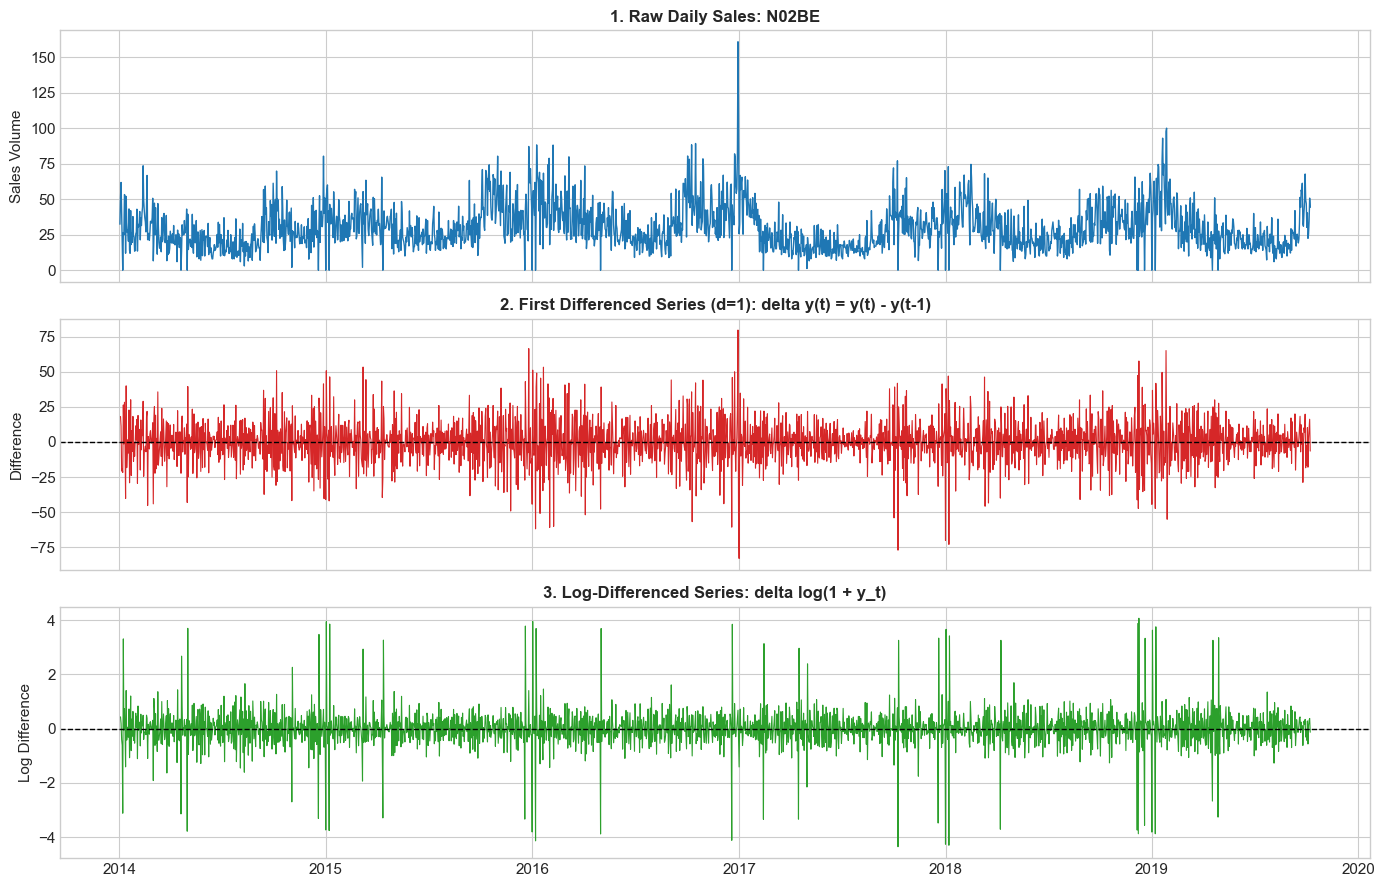

In [7]:
# Visualizing Raw vs First Differenced vs Log-Differenced Series for N02BE
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# 1. Raw
axes[0].plot(df_daily.index, df_daily['N02BE'], color='#1f77b4', linewidth=1)
axes[0].set_title("1. Raw Daily Sales: N02BE", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sales Volume")

# 2. First Difference (d=1)
axes[1].plot(df_daily.index[1:], df_daily['N02BE'].diff().dropna(), color='#d62728', linewidth=0.8)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title("2. First Differenced Series (d=1): delta y(t) = y(t) - y(t-1)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Difference")

# 3. Log-Differenced
log_diff = np.log1p(df_daily['N02BE']).diff().dropna()
axes[2].plot(df_daily.index[1:], log_diff, color='#2ca02c', linewidth=0.8)
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].set_title("3. Log-Differenced Series: delta log(1 + y_t)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Log Difference")

plt.tight_layout()
plt.show()


## 35. Summary of Findings & Key Takeaways

Below is the consolidated summary of the Stationarity and Differencing Analysis across modules 31 through 34:

| Analysis Module | Metric / Test | Raw Series Result | Differenced Series Result ($d=1$) | Modeling Action |
| :--- | :--- | :--- | :--- | :--- |
| **31. Stationarity Audit** | Rolling Mean & Variance | Fluctuating variance across years | Variance stabilized | Transform via $\log(1+y)$ prior to modeling. |
| **32. ADF Test** | Unit Root ($H_0$: Non-stationary) | $p < 0.001$ (Rejects $H_0$) | $p < 10^{-20}$ (Rejects $H_0$) | Confirms absence of stochastic unit root. |
| **33. KPSS Test** | Stationarity ($H_0$: Stationary) | $p = 0.0100$ (Rejects $H_0$) | $p = 0.1000$ (Fails to Reject $H_0$) | Confirms raw series is difference-stationary. |
| **34. Differencing ($d=1$)**| Joint ADF + KPSS Status | Difference Stationary | **100% STRICTLY STATIONARY** | Set order of differencing $d=1$ in ARIMA/SARIMAX models. |

---

### Final Time-Series Modeling Roadmap
1. **ARIMA / SARIMAX Parameterization**: Set integration parameter $d=1$ to satisfy strict stationarity under both ADF and KPSS criteria.
2. **Gradient Boosting Target Strategy**: Apply log transformation $\log(1+y_t)$ as the regression target for LightGBM/XGBoost to ensure constant variance ($\sigma^2$) across all sales volume ranges.
